In [2]:
%matplotlib inline
import torch
from d2l import torch as d2l
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [7]:
def read_img(img_path):
    try:
        img = mpimg.imread(img_path)
        return img
    except FileNotFoundError:
        print(f'找不到文件{img_path}')
        return None
def show_img(img):
    if img is not None:
        plt.imshow(img)

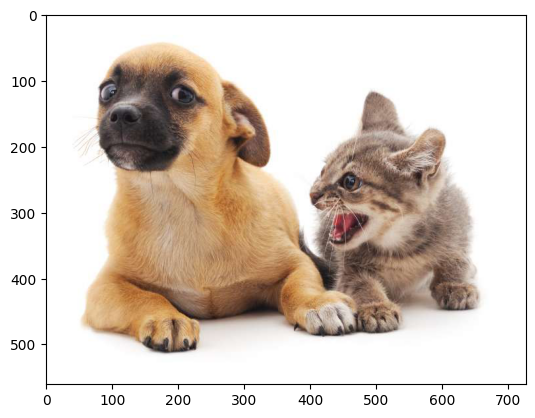

In [8]:
img = read_img('../img/catdog.jpg')
show_img(img)

In [10]:
h, w = img.shape[:2]
print(h, w)

561 728


In [11]:
def display_anchors(fmap_w, fmap_h, s):
    d2l.set_figsize()
    # 自定义一个featuremap的尺寸，第一个是batch_size，第二个是channels，这两个值不影响锚框数量
    fmap = torch.zeros((1, 10, fmap_h, fmap_w))
    
    # multibox_prior(data, sizes, ratios) 生成以每个像素为中心的锚框；返回值：返回所有锚框的坐标（左上、右下坐标系），shape: (1, boxes_per_pixel*n_width*in_height, 4)
    anchors = d2l.multibox_prior(fmap, sizes=s, ratios=[1, 2, 0.5]) 

    # 因为返回的anchors是归一化的值，所以为了还原到原图，需要加入原图的尺寸缩放；因为anchors返回的是左上、右下的坐标系，所以分别要×w和h
    bbox_scale = torch.tensor((w, h, w, h))
    d2l.show_bboxes(d2l.plt.imshow(img).axes, anchors[0] * bbox_scale)

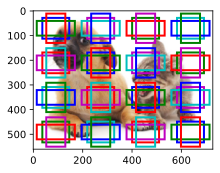

In [12]:
display_anchors(fmap_w=4, fmap_h=4, s=[0.15])

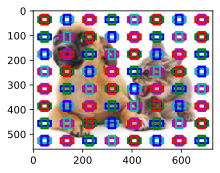

In [16]:
display_anchors(fmap_w=8, fmap_h=8, s=[0.05])

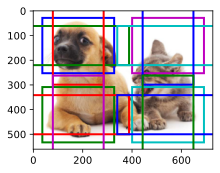

In [18]:
display_anchors(fmap_w=2, fmap_h=2, s=[0.4])

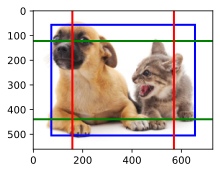

In [19]:
display_anchors(fmap_w=1, fmap_h=1, s=[0.8])